# 2. 매출 이상치 플래그별 심층 분석

| 분석 대상 | 주요 질문 |
|-----------|----------|
| **① REFUND_NEGATIVE** | 어떤 상품이 주로 환불되며, 구매→환불 시간 텀은? |
| **② GIFT_OR_ZERO_QTY** | 같은 거래에 동일 상품의 정상 구매가 공존하는가? (증정품 여부) |
| **③ ZERO_AMT_NEG_QTY** | 실데이터 육안 확인 — 어떤 성격의 데이터인가? |
| **④ PARTIAL_CANCEL** | 어떤 상품이 주로 부분 취소되며, 취소 시간 텀은? |

## 0. 공통 설정

In [3]:
import os, gc, warnings
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

# ── 한글 폰트 ────────────────────────────────────────────────────────────────
plt.rcParams['font.family']       = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 120

# ── 경로 설정 ────────────────────────────────────────────────────────────────
BASE_DIR    = r'C:\Users\alexj\2026_캡스톤_디자인\세븐일레븐_프로젝트\세븐일레븐_내부데이터'
FINAL_DIR   = os.path.join(BASE_DIR, '전처리_EDA', '최종')
PATH_MAIN   = os.path.join(FINAL_DIR, 'df_전처리완료.parquet')    # 전체 (~2.9 GB)
PATH_REVIEW = os.path.join(FINAL_DIR, 'df_이상치_검토용.parquet') # 이상치만 (~124 MB)

# ── 컬럼 목록 (결측치_요약.csv 기반으로 확인된 실제 컬럼) ────────────────────
ALL_COLS = [
    '영업일자', '판매시분초', '점포코드', 'POS번호', '거래번호',
    '상품코드', '상품명', '상품대분류명', '상품중분류명', '상품소분류명',
    '매출수량', '매출금액',
    '판매시간_dt', '판매월', '판매주', '판매일', '판매요일', '판매시간대',
    '거래_고유키', 'flag_이상치_유형',
]

print('✅ 설정 완료')

✅ 설정 완료


## 이상치 분리본 로드 (전체 플래그 포함, ~124 MB)

In [4]:
df_review = pd.read_parquet(PATH_REVIEW)
df_review['판매시간_dt'] = pd.to_datetime(df_review['판매시간_dt'], errors='coerce')

print(f'✅ 이상치 데이터 로드: {len(df_review):,}행 × {len(df_review.columns)}열')
print(f'   메모리: {df_review.memory_usage(deep=True).sum()/1e6:.1f} MB\n')

# 플래그 분포
flag_dist = df_review['flag_이상치_유형'].value_counts()
total     = len(df_review)
print('[이상치 플래그 분포]')
for flag, cnt in flag_dist.items():
    print(f'  {flag:<25} : {cnt:>10,}행  ({cnt/total*100:>6.3f}%)')

✅ 이상치 데이터 로드: 3,337,300행 × 20열
   메모리: 1941.6 MB

[이상치 플래그 분포]
  REFUND_NEGATIVE           :  2,090,702행  (62.647%)
  GIFT_OR_ZERO_QTY          :  1,192,591행  (35.735%)
  ZERO_AMT_NEG_QTY          :     53,039행  ( 1.589%)
  DATA_SUSPECT              :        952행  ( 0.029%)
  PARTIAL_CANCEL            :         16행  ( 0.000%)
  NORMAL                    :          0행  ( 0.000%)


---
## ① REFUND_NEGATIVE — 환불 분석

**수량 < 0 AND 금액 < 0** 인 행으로, 편의점 POS에서 반품/환불 처리 시 발생하는 레코드입니다.

1. 어떤 상품·카테고리가 주로 환불되는가?
2. 환불은 어느 시간대/요일에 집중되는가?
3. 구매→환불까지 시간 텀은 얼마나 되는가?

In [5]:
df_refund = df_review[df_review['flag_이상치_유형'] == 'REFUND_NEGATIVE'].copy()
print(f'REFUND_NEGATIVE: {len(df_refund):,}행')
print(f'  관련 상품 수      : {df_refund["상품코드"].nunique():,}개')
print(f'  관련 점포 수      : {df_refund["점포코드"].nunique():,}개')
print(f'  환불 금액 합계    : {df_refund["매출금액"].sum():,.0f}원')
print(f'  평균 환불 금액    : {df_refund["매출금액"].mean():,.0f}원')
df_refund[['상품명', '상품소분류명', '매출수량', '매출금액', '판매시간_dt']].head(5)

REFUND_NEGATIVE: 2,090,702행
  관련 상품 수      : 12,197개
  관련 점포 수      : 454개
  환불 금액 합계    : -15,592,031,232원
  평균 환불 금액    : -7,458원


,상품명,상품소분류명,매출수량,매출금액,판매시간_dt
1,칠성)핫식스더킹퍼플355ml,에너지음료,-2.0,-4600.0,2025-05-23 14:05:30
2,롯데)왓따콜라23g,풍선껌,-1.0,-600.0,2025-05-23 16:05:25
3,롯데)스크류바75ml,바,-1.0,-1500.0,2025-05-23 01:51:11
4,롯데)잇츠와플바닐라140ml,모나카,-3.0,-6600.0,2025-05-23 01:26:33
6,롯데)몽쉘오리지널204g,파이,-1.0,-3500.0,2025-05-23 08:36:51


### ① - 1. 상위 환불 상품 & 카테고리

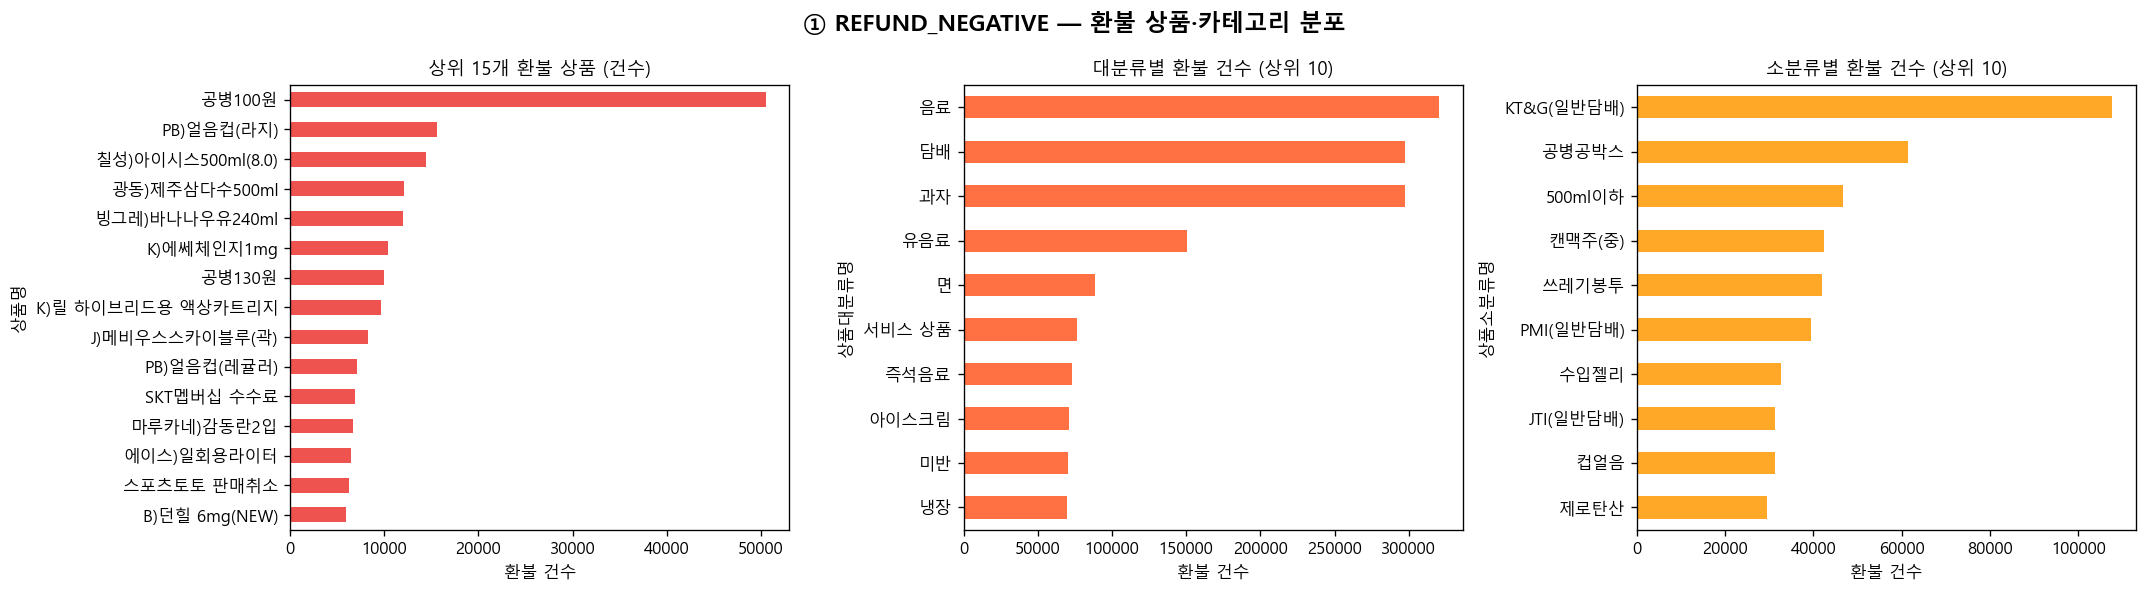


[상위 15개 환불 상품 세부]


,건수,환불금액합
상품명,,
공병100원,50524,-75494096.0
PB)얼음컵(라지),15578,-20203510.0
칠성)아이시스500ml(8.0),14399,-31874984.0
광동)제주삼다수500ml,12065,-29075190.0
빙그레)바나나우유240ml,11951,-29540620.0
K)에쎄체인지1mg,10379,-105907504.0
공병130원,10013,-11132680.0
K)릴 하이브리드용 액상카트리지,9644,-20551000.0
J)메비우스스카이블루(곽),8293,-90337504.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('① REFUND_NEGATIVE — 환불 상품·카테고리 분포', fontsize=14, fontweight='bold')

# 상위 상품 (건수 기준)
top_item_refund = df_refund.groupby('상품명').agg(
    건수=('매출수량', 'count'),
    환불금액합=('매출금액', 'sum')
).sort_values('건수', ascending=False).head(15)

top_item_refund['건수'].plot(kind='barh', ax=axes[0], color='#EF5350')
axes[0].set_title('상위 15개 환불 상품 (건수)', fontsize=11)
axes[0].set_xlabel('환불 건수')
axes[0].invert_yaxis()

# 대분류별 환불 건수
cat_l = df_refund['상품대분류명'].value_counts().head(10)
cat_l.plot(kind='barh', ax=axes[1], color='#FF7043')
axes[1].set_title('대분류별 환불 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('환불 건수')
axes[1].invert_yaxis()

# 소분류별 환불 건수
cat_s = df_refund['상품소분류명'].value_counts().head(10)
cat_s.plot(kind='barh', ax=axes[2], color='#FFA726')
axes[2].set_title('소분류별 환불 건수 (상위 10)', fontsize=11)
axes[2].set_xlabel('환불 건수')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_refund_products.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n[상위 15개 환불 상품 세부]')
display(top_item_refund)

### ① - 2. 시간대 / 요일 환불 패턴

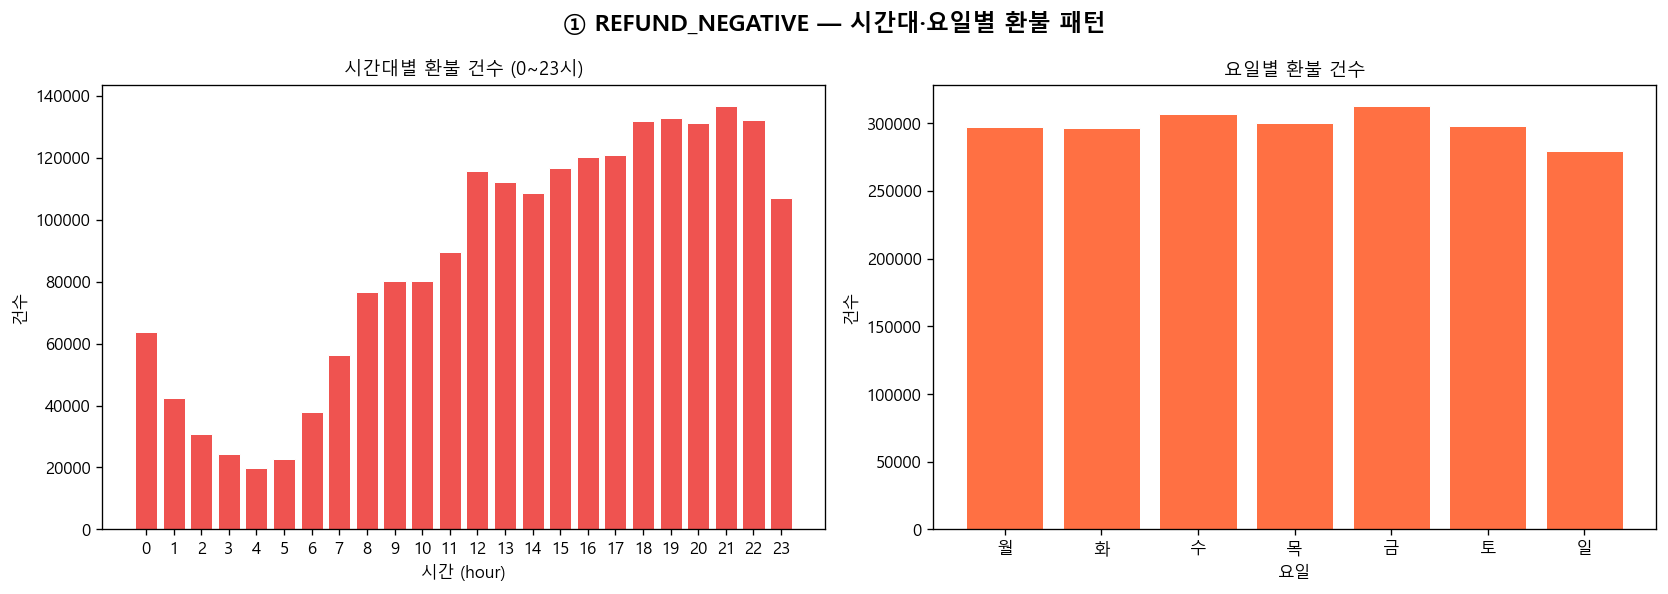

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('① REFUND_NEGATIVE — 시간대·요일별 환불 패턴', fontsize=14, fontweight='bold')

# 시간대별
hour_dist = df_refund['판매시간대'].value_counts().sort_index()
axes[0].bar(hour_dist.index, hour_dist.values, color='#EF5350', edgecolor='white', linewidth=0.6)
axes[0].set_title('시간대별 환불 건수 (0~23시)', fontsize=11)
axes[0].set_xlabel('시간 (hour)')
axes[0].set_ylabel('건수')
axes[0].set_xticks(range(0, 24))

# 요일별
day_order = ['월', '화', '수', '목', '금', '토', '일']
day_dist  = df_refund['판매요일'].value_counts().reindex(day_order).fillna(0)
axes[1].bar(day_dist.index, day_dist.values, color='#FF7043', edgecolor='white', linewidth=0.6)
axes[1].set_title('요일별 환불 건수', fontsize=11)
axes[1].set_xlabel('요일')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_refund_time_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()

### ① - 3. 환불 시간 텀 분석

동일 점포·상품 기준으로 환불 직전 **가장 가까운 정상 구매 시점**을 찾아 시간 텀을 계산합니다.  
> ⏳ 메인 파일(2.9 GB)에서 해당 상품의 NORMAL 행을 로드하므로 시간이 걸릴 수 있습니다.

In [8]:
# ── 상위 50개 환불 상품만 대상으로 분석 (메모리·시간 절감) ──────────────────
TOP_N = 50
top_refund_items = df_refund['상품코드'].value_counts().head(TOP_N).index.tolist()
print(f'시간 텀 분석 대상: 상위 {TOP_N}개 상품')

# ── 해당 상품의 NORMAL 행 로드 ────────────────────────────────────────────────
print('메인 Parquet에서 NORMAL 행 로드 중...')
df_normal_r = pd.read_parquet(
    PATH_MAIN,
    columns=['점포코드', '상품코드', '상품명', '판매시간_dt'],
    filters=[
        ('flag_이상치_유형', '=', 'NORMAL'),
        ('상품코드', 'in', top_refund_items)
    ]
)
df_normal_r['판매시간_dt'] = pd.to_datetime(df_normal_r['판매시간_dt'], errors='coerce')
df_normal_r = df_normal_r.dropna(subset=['판매시간_dt'])
print(f'  NORMAL 행 로드 완료: {len(df_normal_r):,}행')

# ── merge_asof: 각 환불에 대해 직전 가장 가까운 정상 구매 매칭 ─────────────
refund_sub = (
    df_refund[df_refund['상품코드'].isin(top_refund_items)]
    [['점포코드', '상품코드', '상품명', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '환불시간'})
    .dropna(subset=['환불시간'])
    .sort_values('환불시간')
)
normal_sub = (
    df_normal_r[['점포코드', '상품코드', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '구매시간'})
    .sort_values('구매시간')
)

df_gap_r = pd.merge_asof(
    refund_sub,
    normal_sub,
    left_on='환불시간',
    right_on='구매시간',
    by=['점포코드', '상품코드'],
    direction='backward'   # 환불 직전 가장 가까운 구매
)
df_gap_r['시간_텀_h'] = (df_gap_r['환불시간'] - df_gap_r['구매시간']).dt.total_seconds() / 3600
df_gap_r['일_텀']    = (df_gap_r['시간_텀_h'] / 24).round(1)

valid_gap = df_gap_r.dropna(subset=['시간_텀_h'])
valid_gap = valid_gap[valid_gap['시간_텀_h'] >= 0]  # 음수(매칭 실패) 제거

매칭률 = len(valid_gap) / len(refund_sub) * 100
print(f'\n매칭 성공: {len(valid_gap):,}건 / {len(refund_sub):,}건 ({매칭률:.1f}%)')
print(f'  중앙 시간 텀 : {valid_gap["시간_텀_h"].median():.1f}시간')
print(f'  평균 시간 텀 : {valid_gap["시간_텀_h"].mean():.1f}시간')
print(f'  중앙 일수 텀 : {valid_gap["일_텀"].median():.1f}일')

del df_normal_r
gc.collect()

시간 텀 분석 대상: 상위 50개 상품
메인 Parquet에서 NORMAL 행 로드 중...
  NORMAL 행 로드 완료: 15,463,308행

매칭 성공: 318,026건 / 340,299건 (93.5%)
  중앙 시간 텀 : 0.0시간
  평균 시간 텀 : 161.5시간
  중앙 일수 텀 : 0.0일


18

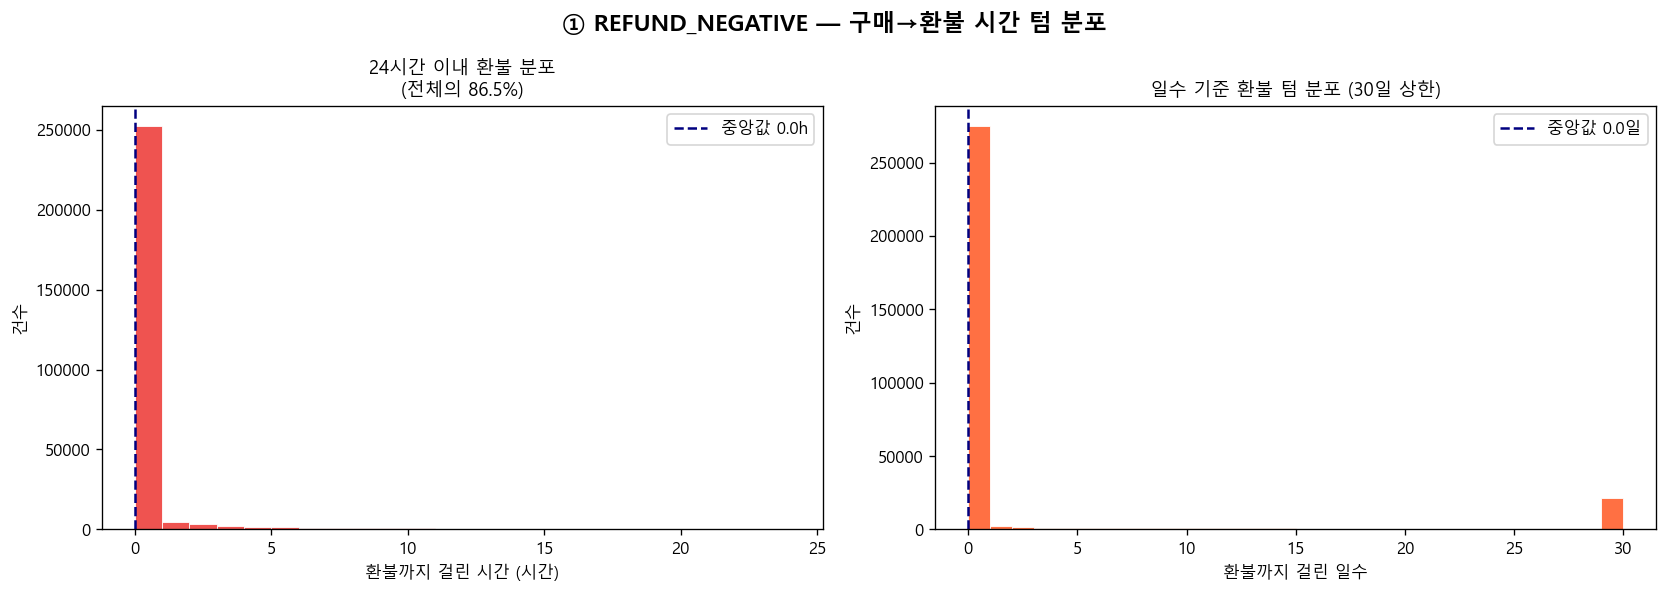

[환불 텀 구간 비중]
  당일(0~24h)   : 275,037건  (86.5%)
  1~3일        :   3,650건  (1.1%)
  3~7일        :   4,473건  (1.4%)
  7일 초과       :  34,866건  (11.0%)


In [9]:
# 시간 텀 히스토그램 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('① REFUND_NEGATIVE — 구매→환불 시간 텀 분포', fontsize=14, fontweight='bold')

# 24시간 이내 (당일 환불)
within_24h = valid_gap[valid_gap['시간_텀_h'] <= 24]['시간_텀_h']
axes[0].hist(within_24h, bins=24, color='#EF5350', edgecolor='white', linewidth=0.5)
axes[0].set_title(f'24시간 이내 환불 분포\n(전체의 {len(within_24h)/len(valid_gap)*100:.1f}%)', fontsize=11)
axes[0].set_xlabel('환불까지 걸린 시간 (시간)')
axes[0].set_ylabel('건수')
axes[0].axvline(within_24h.median(), color='navy', linestyle='--', label=f'중앙값 {within_24h.median():.1f}h')
axes[0].legend()

# 일수 기준 (전체 분포, 30일 상한)
day_dist = valid_gap['일_텀'].clip(upper=30)
axes[1].hist(day_dist, bins=30, color='#FF7043', edgecolor='white', linewidth=0.5)
axes[1].set_title('일수 기준 환불 텀 분포 (30일 상한)', fontsize=11)
axes[1].set_xlabel('환불까지 걸린 일수')
axes[1].set_ylabel('건수')
axes[1].axvline(valid_gap['일_텀'].median(), color='navy', linestyle='--',
                label=f'중앙값 {valid_gap["일_텀"].median():.1f}일')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_refund_time_gap.png'), dpi=150, bbox_inches='tight')
plt.show()

# 당일(0~24h) / 1~3일 / 3일+ 비중
print('[환불 텀 구간 비중]')
for label, lo, hi in [('당일(0~24h)', 0, 24), ('1~3일', 24, 72), ('3~7일', 72, 168), ('7일 초과', 168, 1e9)]:
    cnt = ((valid_gap['시간_텀_h'] >= lo) & (valid_gap['시간_텀_h'] < hi)).sum()
    print(f'  {label:<12}: {cnt:>7,}건  ({cnt/len(valid_gap)*100:.1f}%)')

### 환불 이상치 결론:

- 상품명 in ('공병', '수수료') 삭제
- 환불되어 취소된 수량 및 금액은 추후 상품 단위로 묶일 때 음수로 반영되어야 하므로 유지

---
## ② GIFT_OR_ZERO_QTY — 증정품 여부 확인

**수량=0 OR 금액=0** 인 행. 주요 가설:
- 번들증정(N+1) 행사에서 무료 제공되는 상품 → **동일 거래에 정상 구매 행 공존 여부** 확인
- 금액=0인데 수량>0 : 증정품 가능성 높음
- 수량=0 : POC 단위 집계 오류 또는 취소 후 재처리 가능성

In [10]:
df_gift = df_review[df_review['flag_이상치_유형'] == 'GIFT_OR_ZERO_QTY'].copy()
print(f'GIFT_OR_ZERO_QTY: {len(df_gift):,}행')

# 세부 구분: AMT=0 / QTY=0 / 둘 다 0
amt0  = (df_gift['매출금액'] == 0) & (df_gift['매출수량'] != 0)
qty0  = (df_gift['매출수량'] == 0) & (df_gift['매출금액'] != 0)
both0 = (df_gift['매출금액'] == 0) & (df_gift['매출수량'] == 0)

print(f'\n  금액=0, 수량>0 (증정품 유력)  : {amt0.sum():>8,}건  ({amt0.sum()/len(df_gift)*100:.2f}%)')
print(f'  수량=0, 금액>0 (집계 오류 의심): {qty0.sum():>8,}건  ({qty0.sum()/len(df_gift)*100:.2f}%)')
print(f'  수량=0, 금액=0 (완전 0건)      : {both0.sum():>8,}건  ({both0.sum()/len(df_gift)*100:.2f}%)')
print()

# 수량 분포 (amt=0인 행)
print('[금액=0 행의 매출수량 분포]')
display(df_gift[amt0]['매출수량'].value_counts().head(10).to_frame())

GIFT_OR_ZERO_QTY: 1,192,591행

  금액=0, 수량>0 (증정품 유력)  : 1,192,514건  (99.99%)
  수량=0, 금액>0 (집계 오류 의심):        0건  (0.00%)
  수량=0, 금액=0 (완전 0건)      :       77건  (0.01%)

[금액=0 행의 매출수량 분포]


,count
매출수량,
1.0,928664
2.0,179890
3.0,47940
4.0,19882
5.0,8345
6.0,4559
7.0,1051
10.0,676
8.0,567


### ② - 1. 상위 증정 상품 & 카테고리

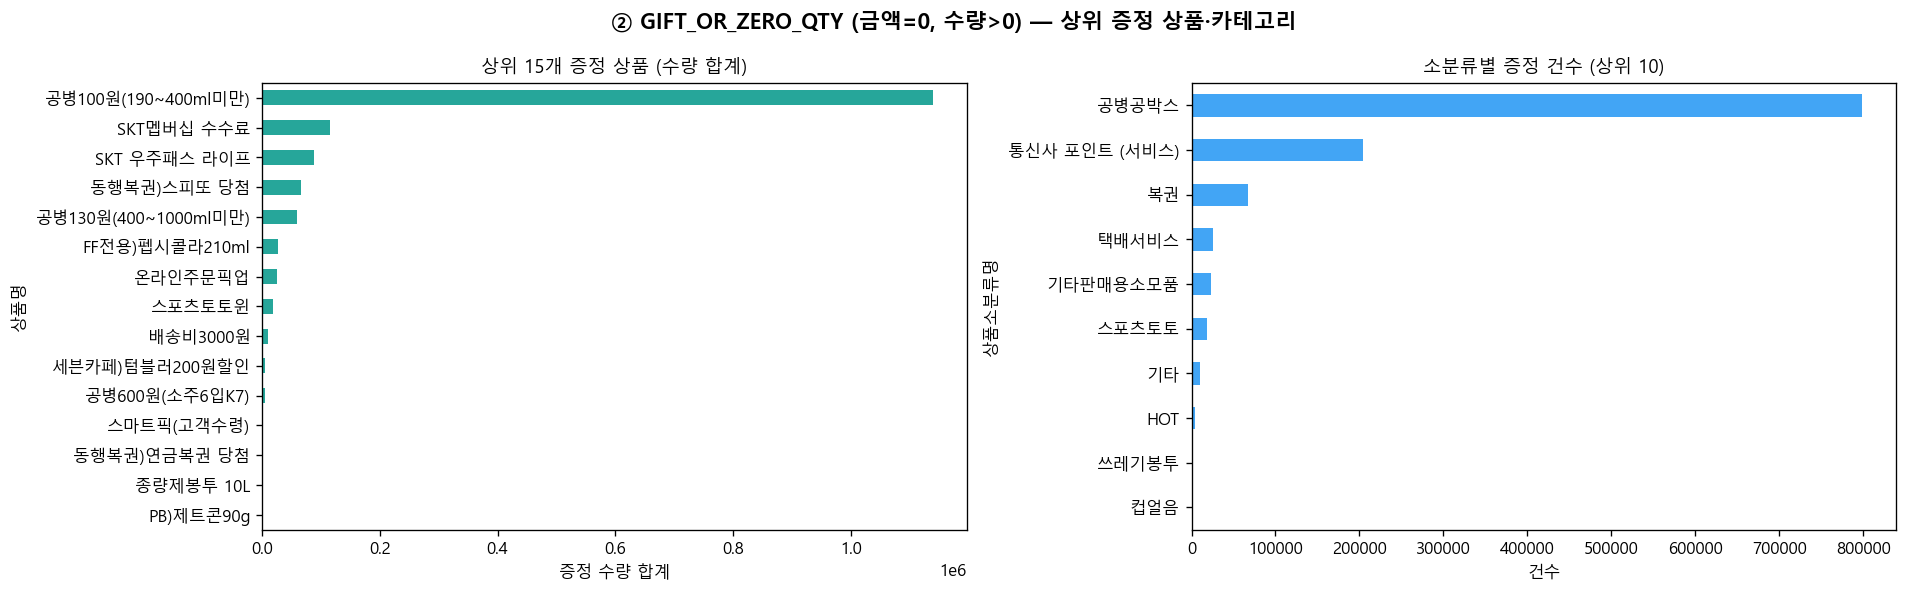

In [11]:
# 금액=0, 수량>0 행만 (증정품 유력)
df_gift_amt0 = df_gift[amt0].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('② GIFT_OR_ZERO_QTY (금액=0, 수량>0) — 상위 증정 상품·카테고리', fontsize=13, fontweight='bold')

top_gift_items = df_gift_amt0.groupby('상품명')['매출수량'].sum().sort_values(ascending=False).head(15)
top_gift_items.plot(kind='barh', ax=axes[0], color='#26A69A')
axes[0].set_title('상위 15개 증정 상품 (수량 합계)', fontsize=11)
axes[0].set_xlabel('증정 수량 합계')
axes[0].invert_yaxis()

top_gift_cat = df_gift_amt0['상품소분류명'].value_counts().head(10)
top_gift_cat.plot(kind='barh', ax=axes[1], color='#42A5F5')
axes[1].set_title('소분류별 증정 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('건수')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_gift_products.png'), dpi=150, bbox_inches='tight')
plt.show()

### ② - 2. 동일 거래 내 정상 구매 공존 여부 (증정품 검증)

샘플 거래의 전체 영수증 구성을 불러와,  
*금액=0 행과 동일 상품코드의 정상 구매(NORMAL)가 같은 거래에 존재하는지* 확인합니다.  
→ 존재하면 **번들증정 증정행**, 없으면 **다른 원인(시스템 보정 등)** 가능성.

> ⏳ 메인 파일에서 샘플 거래를 로드합니다.

In [12]:
# 금액=0 행에서 샘플 거래_고유키 추출 (최대 300건)
SAMPLE_N = 300
gift_sample_keys = (
    df_gift_amt0['거래_고유키'].drop_duplicates()
    .sample(n=min(SAMPLE_N, df_gift_amt0['거래_고유키'].nunique()), random_state=42)
    .tolist()
)
print(f'샘플 거래 수: {len(gift_sample_keys):,}건')

# 해당 거래의 전체 행 로드 (메인 파일에서 거래_고유키 필터)
print('메인 Parquet에서 샘플 거래 전체 행 로드 중...')
df_gift_tx = pd.read_parquet(
    PATH_MAIN,
    columns=['거래_고유키', '상품코드', '상품명', '매출수량', '매출금액', 'flag_이상치_유형'],
    filters=[('거래_고유키', 'in', gift_sample_keys)]
)
print(f'  로드 완료: {len(df_gift_tx):,}행')

# 증정행(금액=0)과 정상행(NORMAL) 각각 추출
gift_rows   = df_gift_tx[df_gift_tx['매출금액'] == 0][['거래_고유키', '상품코드']].rename(columns={'상품코드': '증정_상품코드'})
normal_rows = df_gift_tx[df_gift_tx['flag_이상치_유형'] == 'NORMAL'][['거래_고유키', '상품코드']].rename(columns={'상품코드': '정상_상품코드'})

# 동일 거래 내 동일 상품 공존 여부
cooc = gift_rows.merge(normal_rows, on='거래_고유키')
same_item_cooc = cooc[cooc['증정_상품코드'] == cooc['정상_상품코드']]
diff_item_cooc = cooc[cooc['증정_상품코드'] != cooc['정상_상품코드']]

cooc_tx = same_item_cooc['거래_고유키'].nunique()
only_gift_tx = len(set(gift_sample_keys) - set(normal_rows['거래_고유키']))

print(f'\n[샘플 {len(gift_sample_keys)}건 분석 결과]')
print(f'  동일 상품 정상 구매 공존 (증정품 확인)  : {cooc_tx:>5}건  ({cooc_tx/len(gift_sample_keys)*100:.1f}%)')
print(f'  다른 상품 정상 구매 공존 (복합 영수증)   : {diff_item_cooc["거래_고유키"].nunique():>5}건')
print(f'  정상 구매 없이 증정행만 존재             : {only_gift_tx:>5}건  ({only_gift_tx/len(gift_sample_keys)*100:.1f}%)')
print()
if cooc_tx > 0:
    print('→ 동일 상품 공존 비율이 높으면 N+1 번들증정 증정행으로 판단 가능')
if only_gift_tx > 0:
    print('→ 정상 구매 없는 증정행은 별도 원인 분석 필요 (재고 조정, 시스템 보정 등)')

del df_gift_tx
gc.collect()

샘플 거래 수: 300건
메인 Parquet에서 샘플 거래 전체 행 로드 중...
  로드 완료: 1,549행

[샘플 300건 분석 결과]
  동일 상품 정상 구매 공존 (증정품 확인)  :    51건  (17.0%)
  다른 상품 정상 구매 공존 (복합 영수증)   :   296건
  정상 구매 없이 증정행만 존재             :     4건  (1.3%)

→ 동일 상품 공존 비율이 높으면 N+1 번들증정 증정행으로 판단 가능
→ 정상 구매 없는 증정행은 별도 원인 분석 필요 (재고 조정, 시스템 보정 등)


17398

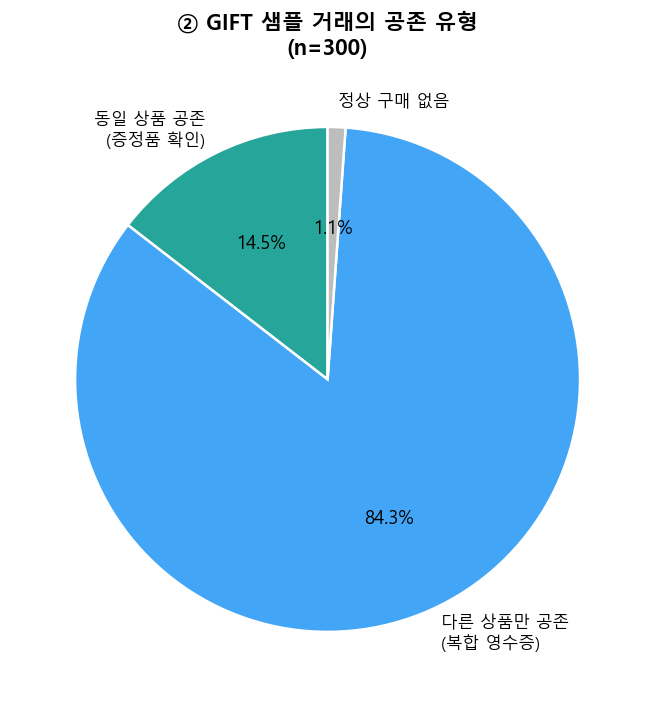

In [13]:
# 파이차트: 공존 유형 분포
labels = ['동일 상품 공존\n(증정품 확인)', '다른 상품만 공존\n(복합 영수증)', '정상 구매 없음']
sizes  = [
    cooc_tx,
    diff_item_cooc['거래_고유키'].nunique(),
    only_gift_tx
]
colors = ['#26A69A', '#42A5F5', '#BDBDBD']

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title(f'② GIFT 샘플 거래의 공존 유형\n(n={len(gift_sample_keys)})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_gift_cooccurrence.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 동일 거래 내 이상치 상품과 동일한 카테고리(소분류)가 있는지 점검

### 수량 = 0 or 금액 = 0 이상치 결론:

- 상품소분류명 in ('공병공박스', '통신사 포인트 (서비스)') 제거
- 동일 거래 내 동일 '카테고리(소분류)'가 있는지 또한 분석해서 정확한 번들증정 여부를 파악해야 함.

---
## ③ ZERO_AMT_NEG_QTY — 육안 데이터 검토

**수량 < 0 AND 금액 = 0** 인 행.  
물리적 해석: "마이너스 수량인데 돈은 안 건드린" 케이스.  
가능한 원인: **재고 조정, 파손/폐기 처리, 번들 취소 후 재처리** 등

In [14]:
df_zero_neg = df_review[df_review['flag_이상치_유형'] == 'ZERO_AMT_NEG_QTY'].copy()
print(f'ZERO_AMT_NEG_QTY: {len(df_zero_neg):,}행')
print(f'  관련 상품 수: {df_zero_neg["상품코드"].nunique():,}개')
print(f'  관련 점포 수: {df_zero_neg["점포코드"].nunique():,}개')
print(f'  매출수량 통계:')
print(df_zero_neg['매출수량'].describe().to_string())

ZERO_AMT_NEG_QTY: 53,039행
  관련 상품 수: 6,282개
  관련 점포 수: 449개
  매출수량 통계:
count    53039.000000
mean        -1.451140
std          4.788875
min       -575.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max         -1.000000


In [15]:
# 실제 데이터 샘플 출력 (육안 확인)
display_cols = ['영업일자', '판매시분초', '점포코드', 'POS번호', '거래번호',
                '상품코드', '상품명', '상품소분류명', '매출수량', '매출금액', '판매시간_dt']

print('=' * 70)
print('[ZERO_AMT_NEG_QTY 샘플 — 랜덤 20행]')
print('=' * 70)
sample = df_zero_neg.sample(n=min(20, len(df_zero_neg)), random_state=42)
display(sample[[c for c in display_cols if c in df_zero_neg.columns]])

[ZERO_AMT_NEG_QTY 샘플 — 랜덤 20행]


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,상품명,상품소분류명,매출수량,매출금액,판매시간_dt
1779206,20250923,132111,67616,1,87477,315074,B)네오 퍼플 부스트,BAT(전자담배용 담배),-1.0,0.0,2025-09-23 13:21:11
3068067,20251007,133620,64310,2,54585,900072,공병100원(190~400ml미만),공병공박스,-2.0,0.0,2025-10-07 13:36:20
1305618,20250117,65238,69101,2,85908,105078,세븐카페)텀블러200원할인,HOT,-1.0,0.0,2025-01-17 06:52:38
2979392,20251126,130339,68573,2,16844,061713,덴마크)바나바나우유300ml,바나나우유,-1.0,0.0,2025-11-26 13:03:39
1416496,20250409,4902,68390,2,26725,105078,세븐카페)텀블러200원할인,HOT,-1.0,0.0,2025-04-09 00:49:02
2063946,20251111,102942,67468,1,54322,202732,PB)내몸애70% 500ml,500ml이하,-1.0,0.0,2025-11-11 10:29:42
2821488,20251121,124446,19280,3,81802,108563,비노)콜미레이터러시안잭쇼비뇽블랑750ml,화이트,-1.0,0.0,2025-11-21 12:44:46
421488,20250206,221908,67468,1,84558,073509,대광)찰진순대273g,족발/순대,-1.0,0.0,2025-02-06 22:19:08
2139970,20251018,51324,55765,1,97685,180149,아사히)아사히350ml캔(6입),캔맥주(소),-1.0,0.0,2025-10-18 05:13:24
2318039,20250906,13404,67903,2,56112,111992,롯데)목캔디허브(오리지날)38g,기능성캔디,-1.0,0.0,2025-09-06 01:34:04


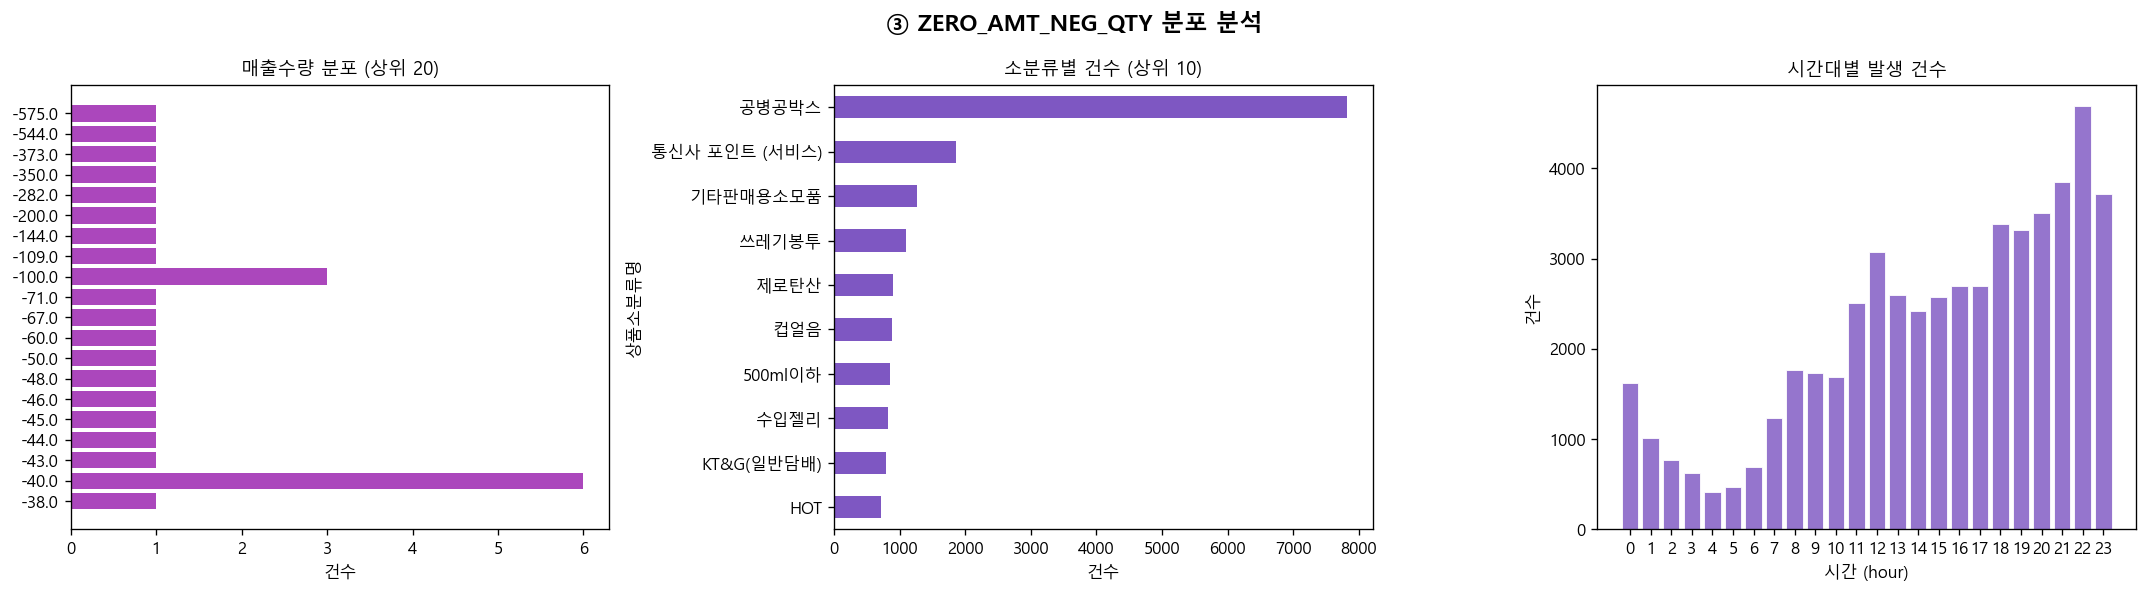


[ZERO_AMT_NEG_QTY 상위 10개 상품]


,,,건수,수량합
상품코드,상품명,상품소분류명,,
900072,공병100원(190~400ml미만),공병공박스,7374,-13376.0
502209,FF전용)펩시콜라210ml,기타판매용소모품,1253,-1398.0
322901,SKT멥버십 수수료,통신사 포인트 (서비스),1181,-1181.0
324685,SKT 우주패스 라이프,통신사 포인트 (서비스),676,-676.0
321281,종량제봉투 10L,쓰레기봉투,432,-822.0
900073,공병130원(400~1000ml미만),공병공박스,403,-941.0
107128,PB)얼음컵(라지),컵얼음,389,-478.0
105078,세븐카페)텀블러200원할인,HOT,372,-461.0
324617,온라인주문픽업,택배서비스,301,-301.0


In [16]:
# 수량별 / 카테고리별 / 점포별 분포
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('③ ZERO_AMT_NEG_QTY 분포 분석', fontsize=14, fontweight='bold')

# 매출수량 분포 (음수)
qty_dist = df_zero_neg['매출수량'].value_counts().sort_index().head(20)
axes[0].barh(qty_dist.index.astype(str), qty_dist.values, color='#AB47BC')
axes[0].set_title('매출수량 분포 (상위 20)', fontsize=11)
axes[0].set_xlabel('건수')
axes[0].invert_yaxis()

# 소분류 분포
cat_dist = df_zero_neg['상품소분류명'].value_counts().head(10)
cat_dist.plot(kind='barh', ax=axes[1], color='#7E57C2')
axes[1].set_title('소분류별 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('건수')
axes[1].invert_yaxis()

# 시간대 분포
hour_dist = df_zero_neg['판매시간대'].value_counts().sort_index()
axes[2].bar(hour_dist.index, hour_dist.values, color='#9575CD', edgecolor='white', linewidth=0.5)
axes[2].set_title('시간대별 발생 건수', fontsize=11)
axes[2].set_xlabel('시간 (hour)')
axes[2].set_ylabel('건수')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_zero_neg_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

# 상위 발생 상품
print('\n[ZERO_AMT_NEG_QTY 상위 10개 상품]')
display(
    df_zero_neg.groupby(['상품코드', '상품명', '상품소분류명'])
    .agg(건수=('매출수량', 'count'), 수량합=('매출수량', 'sum'))
    .sort_values('건수', ascending=False)
    .head(10)
)

### 수량만 음수이고 금액은 0 이상치 결론:

- 상품소분류명 in ('HOT(할인인것 같음)') 제거
- 다른 상품에 대한 이상치는 재고 확인하기 위해서 기록된 것 같기에 우리 분석에서는 삭제

---
## ④ PARTIAL_CANCEL — 부분 취소 분석

**수량 < 0 AND 금액 > 0** 인 행.  
물리적 해석: "수량은 반환했는데 금액은 양수"  
가능한 원인: **부분 취소 후 남은 금액 차액 처리, 쿠폰/포인트 사후 적용**

1. 어떤 상품·카테고리가 주로 부분 취소되는가?
2. 시간대/요일 패턴
3. 구매→취소 시간 텀

In [17]:
df_partial = df_review[df_review['flag_이상치_유형'] == 'PARTIAL_CANCEL'].copy()
print(f'PARTIAL_CANCEL: {len(df_partial):,}행')
print(f'  관련 상품 수      : {df_partial["상품코드"].nunique():,}개')
print(f'  관련 점포 수      : {df_partial["점포코드"].nunique():,}개')
print(f'  수량 통계: min={df_partial["매출수량"].min()}  mean={df_partial["매출수량"].mean():.2f}')
print(f'  금액 통계: min={df_partial["매출금액"].min()}  mean={df_partial["매출금액"].mean():.0f}  max={df_partial["매출금액"].max()}')
df_partial[['상품명', '상품소분류명', '매출수량', '매출금액', '판매시간_dt']].head(5)

PARTIAL_CANCEL: 16행
  관련 상품 수      : 2개
  관련 점포 수      : 10개
  수량 통계: min=-6.0  mean=-1.31
  금액 통계: min=151.0  mean=3333  max=28661.0


,상품명,상품소분류명,매출수량,매출금액,판매시간_dt
396509,스포츠토토 판매취소,스포츠토토,-1.0,151.0,2025-03-09 13:03:00
869358,스포츠토토 판매취소,스포츠토토,-1.0,28661.0,2025-04-21 17:13:46
2071941,스포츠토토 판매취소,스포츠토토,-1.0,597.0,2025-07-13 16:25:42
2291772,스포츠토토 판매취소,스포츠토토,-1.0,298.0,2025-07-13 21:43:14
2292884,스포츠토토 판매취소,스포츠토토,-1.0,597.0,2025-07-13 20:29:48


### ④ - 1. 상위 부분취소 상품 & 카테고리

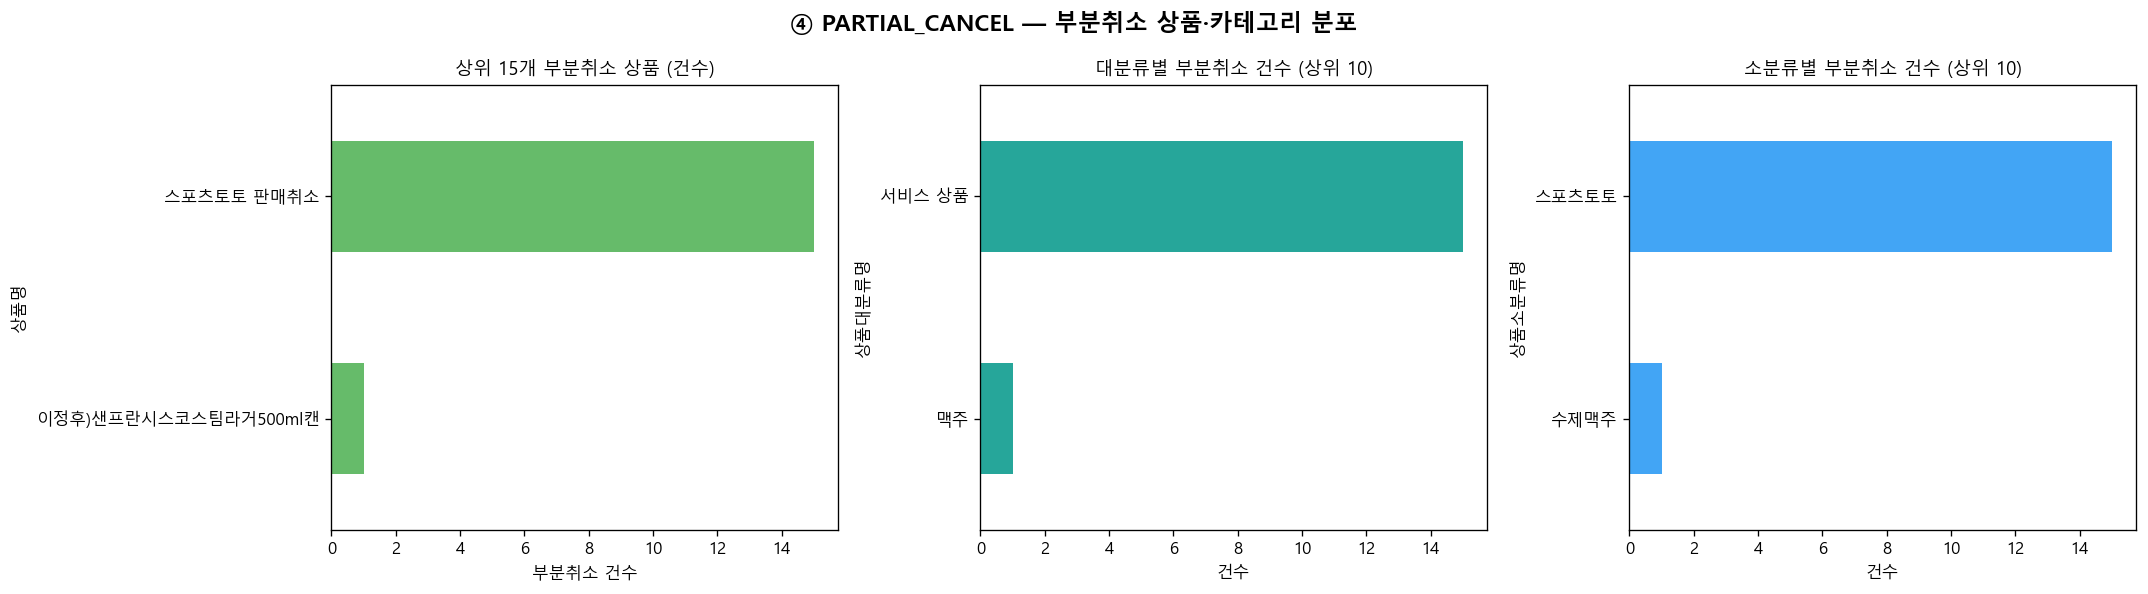


[상위 15개 부분취소 상품 세부]


,건수,금액합
상품명,,
스포츠토토 판매취소,15,47928.0
이정후)샌프란시스코스팀라거500ml캔,1,5400.0


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('④ PARTIAL_CANCEL — 부분취소 상품·카테고리 분포', fontsize=14, fontweight='bold')

# 상위 상품 (건수)
top_pc_items = df_partial.groupby('상품명').agg(
    건수=('매출수량', 'count'),
    금액합=('매출금액', 'sum')
).sort_values('건수', ascending=False).head(15)
top_pc_items['건수'].plot(kind='barh', ax=axes[0], color='#66BB6A')
axes[0].set_title('상위 15개 부분취소 상품 (건수)', fontsize=11)
axes[0].set_xlabel('부분취소 건수')
axes[0].invert_yaxis()

# 대분류 분포
cat_l = df_partial['상품대분류명'].value_counts().head(10)
cat_l.plot(kind='barh', ax=axes[1], color='#26A69A')
axes[1].set_title('대분류별 부분취소 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('건수')
axes[1].invert_yaxis()

# 소분류 분포
cat_s = df_partial['상품소분류명'].value_counts().head(10)
cat_s.plot(kind='barh', ax=axes[2], color='#42A5F5')
axes[2].set_title('소분류별 부분취소 건수 (상위 10)', fontsize=11)
axes[2].set_xlabel('건수')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_partial_products.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n[상위 15개 부분취소 상품 세부]')
display(top_pc_items)

### ④ - 2. 시간대 / 요일 패턴

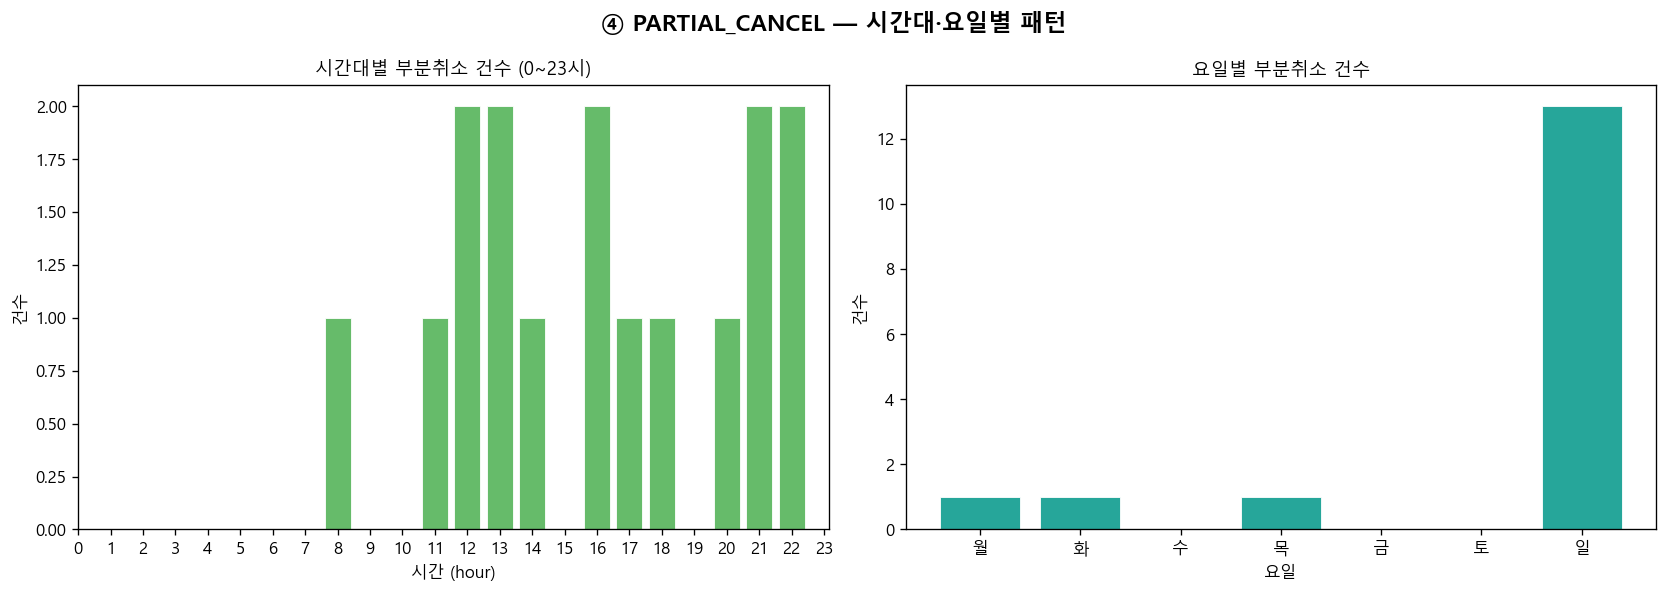

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('④ PARTIAL_CANCEL — 시간대·요일별 패턴', fontsize=14, fontweight='bold')

hour_dist = df_partial['판매시간대'].value_counts().sort_index()
axes[0].bar(hour_dist.index, hour_dist.values, color='#66BB6A', edgecolor='white', linewidth=0.5)
axes[0].set_title('시간대별 부분취소 건수 (0~23시)', fontsize=11)
axes[0].set_xlabel('시간 (hour)')
axes[0].set_ylabel('건수')
axes[0].set_xticks(range(0, 24))

day_order = ['월', '화', '수', '목', '금', '토', '일']
day_dist  = df_partial['판매요일'].value_counts().reindex(day_order).fillna(0)
axes[1].bar(day_dist.index, day_dist.values, color='#26A69A', edgecolor='white', linewidth=0.5)
axes[1].set_title('요일별 부분취소 건수', fontsize=11)
axes[1].set_xlabel('요일')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_partial_time_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()

### ④ - 3. 부분취소 시간 텀 분석

> ⏳ REFUND 분석과 동일한 방식 — 메인 파일에서 해당 상품의 NORMAL 행을 로드합니다.

In [20]:
TOP_N = 50
top_partial_items = df_partial['상품코드'].value_counts().head(TOP_N).index.tolist()
print(f'시간 텀 분석 대상: 상위 {TOP_N}개 상품')

print('메인 Parquet에서 NORMAL 행 로드 중...')
df_normal_p = pd.read_parquet(
    PATH_MAIN,
    columns=['점포코드', '상품코드', '상품명', '판매시간_dt'],
    filters=[
        ('flag_이상치_유형', '=', 'NORMAL'),
        ('상품코드', 'in', top_partial_items)
    ]
)
df_normal_p['판매시간_dt'] = pd.to_datetime(df_normal_p['판매시간_dt'], errors='coerce')
df_normal_p = df_normal_p.dropna(subset=['판매시간_dt'])
print(f'  로드 완료: {len(df_normal_p):,}행')

partial_sub = (
    df_partial[df_partial['상품코드'].isin(top_partial_items)]
    [['점포코드', '상품코드', '상품명', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '취소시간'})
    .dropna(subset=['취소시간'])
    .sort_values('취소시간')
)
normal_p_sub = (
    df_normal_p[['점포코드', '상품코드', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '구매시간'})
    .sort_values('구매시간')
)

df_gap_p = pd.merge_asof(
    partial_sub,
    normal_p_sub,
    left_on='취소시간',
    right_on='구매시간',
    by=['점포코드', '상품코드'],
    direction='backward'
)
df_gap_p['시간_텀_h'] = (df_gap_p['취소시간'] - df_gap_p['구매시간']).dt.total_seconds() / 3600
df_gap_p['일_텀']    = (df_gap_p['시간_텀_h'] / 24).round(1)

valid_gap_p = df_gap_p.dropna(subset=['시간_텀_h'])
valid_gap_p = valid_gap_p[valid_gap_p['시간_텀_h'] >= 0]

매칭률_p = len(valid_gap_p) / len(partial_sub) * 100
print(f'\n매칭 성공: {len(valid_gap_p):,}건 / {len(partial_sub):,}건 ({매칭률_p:.1f}%)')
print(f'  중앙 시간 텀 : {valid_gap_p["시간_텀_h"].median():.1f}시간')
print(f'  평균 시간 텀 : {valid_gap_p["시간_텀_h"].mean():.1f}시간')
print(f'  중앙 일수 텀 : {valid_gap_p["일_텀"].median():.1f}일')

del df_normal_p
gc.collect()

시간 텀 분석 대상: 상위 50개 상품
메인 Parquet에서 NORMAL 행 로드 중...
  로드 완료: 1,765행

매칭 성공: 1건 / 16건 (6.2%)
  중앙 시간 텀 : 0.4시간
  평균 시간 텀 : 0.4시간
  중앙 일수 텀 : 0.0일


30982

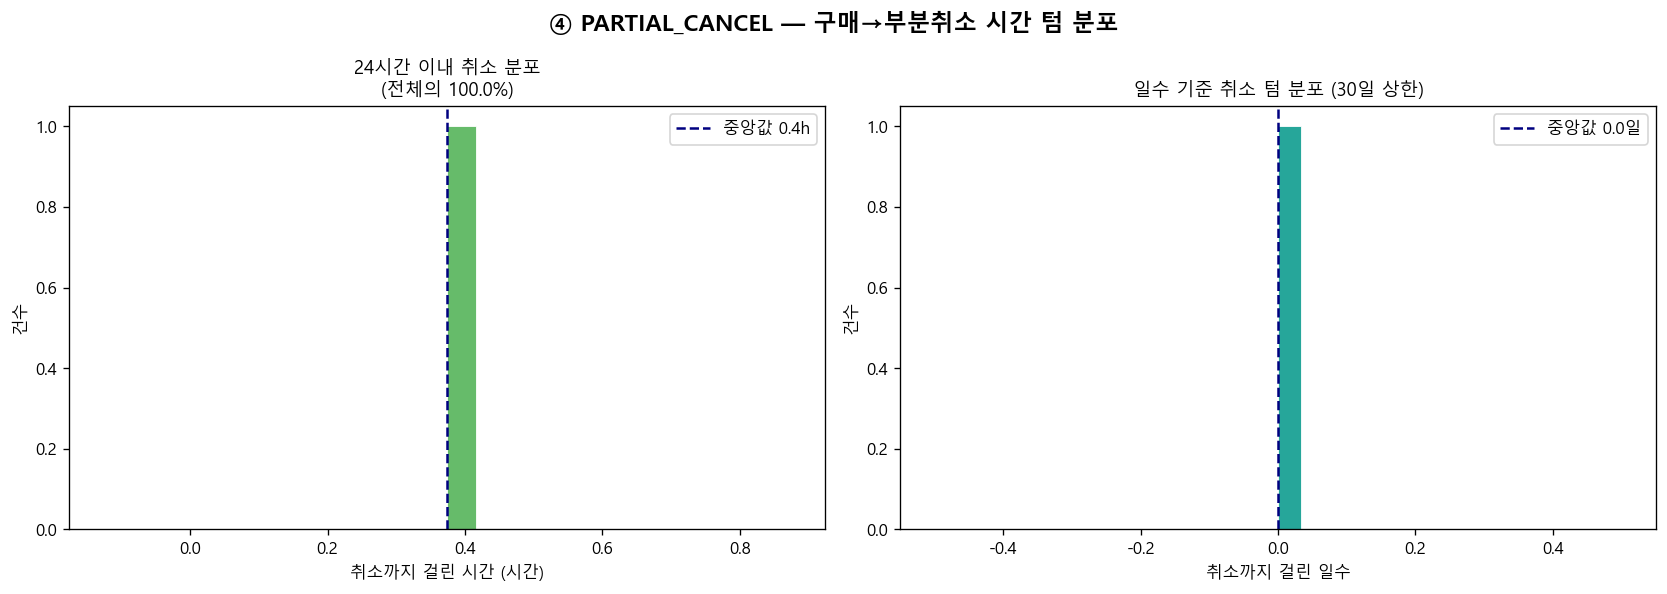

[부분취소 텀 구간 비중]
  당일(0~24h)   :       1건  (100.0%)
  1~3일        :       0건  (0.0%)
  3~7일        :       0건  (0.0%)
  7일 초과       :       0건  (0.0%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('④ PARTIAL_CANCEL — 구매→부분취소 시간 텀 분포', fontsize=14, fontweight='bold')

within_24h_p = valid_gap_p[valid_gap_p['시간_텀_h'] <= 24]['시간_텀_h']
axes[0].hist(within_24h_p, bins=24, color='#66BB6A', edgecolor='white', linewidth=0.5)
axes[0].set_title(f'24시간 이내 취소 분포\n(전체의 {len(within_24h_p)/len(valid_gap_p)*100:.1f}%)', fontsize=11)
axes[0].set_xlabel('취소까지 걸린 시간 (시간)')
axes[0].set_ylabel('건수')
if len(within_24h_p) > 0:
    axes[0].axvline(within_24h_p.median(), color='navy', linestyle='--',
                    label=f'중앙값 {within_24h_p.median():.1f}h')
    axes[0].legend()

day_dist_p = valid_gap_p['일_텀'].clip(upper=30)
axes[1].hist(day_dist_p, bins=30, color='#26A69A', edgecolor='white', linewidth=0.5)
axes[1].set_title('일수 기준 취소 텀 분포 (30일 상한)', fontsize=11)
axes[1].set_xlabel('취소까지 걸린 일수')
axes[1].set_ylabel('건수')
axes[1].axvline(valid_gap_p['일_텀'].median(), color='navy', linestyle='--',
                label=f'중앙값 {valid_gap_p["일_텀"].median():.1f}일')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_partial_time_gap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('[부분취소 텀 구간 비중]')
for label, lo, hi in [('당일(0~24h)', 0, 24), ('1~3일', 24, 72), ('3~7일', 72, 168), ('7일 초과', 168, 1e9)]:
    cnt = ((valid_gap_p['시간_텀_h'] >= lo) & (valid_gap_p['시간_텀_h'] < hi)).sum()
    print(f'  {label:<12}: {cnt:>7,}건  ({cnt/len(valid_gap_p)*100:.1f}%)')

### 수량<0, 금액 >0 이상치 관련

- 상품소분류명 in ('스포츠토토') 제거
- 남은 (이정후맥주) 이상치도 제거

---
## 분석 요약

위 분석 결과를 바탕으로 각 플래그의 처리 방향을 아래 표에 기록하세요.

| 플래그 | 분석 결과 요약 | 처리 방향 (삭제/유지/별도관리) |
|--------|--------------|--------------------------------|
| REFUND_NEGATIVE | | - 상품명 in ('공병', '수수료') 행 제거 - 남은 환불 데이터는 상품 매출 마이너스에 필요함으로 보존|
| GIFT_OR_ZERO_QTY | | - 상품소분류명 in ('공병공박스', '통신사 포인트 (서비스)') 제거 - 동일 거래 내 동일 '카테고리(소분류)'가 있는지 또한 분석해서 정확한 번들증정 여부를 파악해야 함. -> 삭제|
| ZERO_AMT_NEG_QTY | | 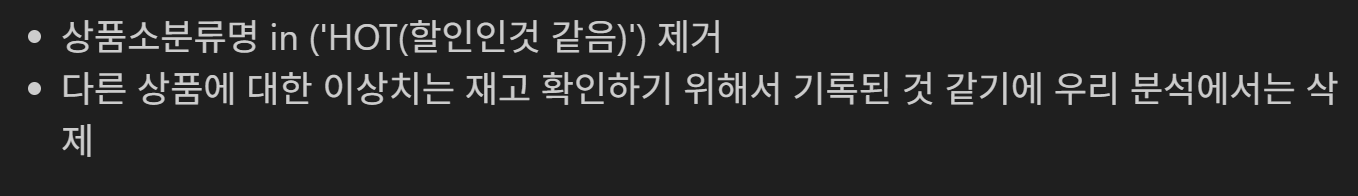|
| PARTIAL_CANCEL | | - 상품소분류명 in ('스포츠토토') 제거 - 남은 (이정후맥주) 이상치도 제거|
| DATA_SUSPECT | 물리적으로 모순(수량+/금액-) → 시스템 오류 유력 | 삭제 |

In [ ]:
# 저장된 시각화 파일 목록 확인
print('💾 저장된 분석 시각화 파일:')
for f in sorted(os.listdir(FINAL_DIR)):
    if f.startswith('fig_') and f.endswith('.png'):
        path = os.path.join(FINAL_DIR, f)
        print(f'  {f}  ({os.path.getsize(path)/1e3:.0f} KB)')